In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import json
import joblib
from datetime import datetime
from sklearn.linear_model import LinearRegression
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeRegressor

In [2]:
df = pd.read_csv("CGWB_data_cleaned.csv")

In [3]:
print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Dataset shape: (28076, 89)
Columns: ['STATE', 'DISTRICT', 'LAT', 'LON', 'SITE_TYPE', 'WLCODE', '05/01/1996', '08/01/1996', '11/01/1996', '01/01/1997', '05/01/1997', '08/01/1997', '11/01/1997', '01/01/1998', '05/01/1998', '08/01/1998', '11/01/1998', '01/01/1999', '05/01/1999', '08/01/1999', '11/01/1999', '01/01/2000', '05/01/2000', '08/01/2000', '11/01/2000', '01/01/2001', '05/01/2001', '08/01/2001', '11/01/2001', '01/01/2002', '05/01/2002', '08/01/2002', '11/01/2002', '01/01/2003', '05/01/2003', '08/01/2003', '11/01/2003', '01/01/2004', '05/01/2004', '08/01/2004', '11/01/2004', '01/01/2005', '05/01/2005', '08/01/2005', '11/01/2005', '01/01/2006', '05/01/2006', '08/01/2006', '11/01/2006', '01/01/2007', '05/01/2007', '08/01/2007', '11/01/2007', '01/01/2008', '05/01/2008', '08/01/2008', '11/01/2008', '01/01/2009', '05/01/2009', '08/01/2009', '11/01/2009', '01/01/2010', '05/01/2010', '08/01/2010', '11/01/2010', '01/01/2011', '05/01/2011', '08/01/2011', '11/01/2011', '01/01/2012', '05/01/20

,STATE,DISTRICT,LAT,LON,SITE_TYPE,WLCODE,05/01/1996,08/01/1996,11/01/1996,01/01/1997,...,11/01/2014,01/01/2015,05/01/2015,08/01/2015,11/01/2015,01/01/2016,05/01/2016,08/01/2016,11/01/2016,01/01/2017
0,TG,Adilabad,19.087222,78.336111,Dug Well,W26026,2.32,2.32,2.32,2.32,...,2.10,2.36,3.86,0.91,2.06,2.32,3.26,1.56,1.71,2.86
1,TG,Adilabad,19.087778,78.401111,Dug Well,W26027,6.03,6.03,6.03,6.03,...,3.93,4.03,7.33,2.39,4.30,2.46,2.46,2.48,1.49,6.03
2,TG,Adilabad,19.170556,77.933611,Dug Well,W26044,7.18,7.18,7.18,7.18,...,3.62,3.47,11.72,3.84,6.82,3.32,11.72,1.28,1.41,11.72
3,TG,Adilabad,19.176667,78.103611,Dug Well,W26046,4.30,4.30,4.30,4.30,...,4.30,4.30,6.30,1.55,5.18,5.21,7.50,2.97,4.03,6.18
4,TG,Adilabad,19.160278,78.634444,Dug Well,W26040,8.60,8.60,8.60,8.60,...,3.67,3.30,4.78,2.77,3.40,3.06,8.65,3.34,5.98,6.75


In [4]:
id_vars = ['STATE', 'DISTRICT', 'LAT', 'LON', 'SITE_TYPE', 'WLCODE']
value_vars = [c for c in df.columns if re.match(r"\d{2}/\d{2}/\d{4}", str(c))]

df_long = df.melt(
    id_vars=id_vars,
    value_vars=value_vars,
    var_name="Date",
    value_name="Ground Water Level"
)

# Convert Date to datetime
df_long["Date"] = pd.to_datetime(df_long["Date"], format="%m/%d/%Y", errors="coerce")

print("✅ Reshaped to long format. Shape:", df_long.shape)
print(df_long.head(10))

✅ Reshaped to long format. Shape: (2330308, 8)
  STATE  DISTRICT        LAT        LON SITE_TYPE  WLCODE       Date  \
0    TG  Adilabad  19.087222  78.336111  Dug Well  W26026 1996-05-01   
1    TG  Adilabad  19.087778  78.401111  Dug Well  W26027 1996-05-01   
2    TG  Adilabad  19.170556  77.933611  Dug Well  W26044 1996-05-01   
3    TG  Adilabad  19.176667  78.103611  Dug Well  W26046 1996-05-01   
4    TG  Adilabad  19.160278  78.634444  Dug Well  W26040 1996-05-01   
5    TG  Adilabad  19.141667  78.339444  Dug Well  W26035 1996-05-01   
6    TG  Adilabad  19.098333  78.780833  Dug Well  W26029 1996-05-01   
7    TG  Adilabad  19.209167  78.876389  Dug Well  W26056 1996-05-01   
8    TG  Adilabad  19.809722  78.464722  Dug Well  W26203 1996-05-01   
9    TG  Adilabad  19.338056  79.334444  Dug Well  W26096 1996-05-01   

   Ground Water Level  
0                2.32  
1                6.03  
2                7.18  
3                4.30  
4                8.60  
5               

In [5]:
df_long["year"] = df_long["Date"].dt.year
df_long["month"] = df_long["Date"].dt.month

# Drop rows with missing target
df_long = df_long.dropna(subset=["Ground Water Level"])

target_col = "Ground Water Level"
use_cols = ['STATE', 'DISTRICT', 'LAT', 'LON', 'SITE_TYPE', 'WLCODE', 'year', 'month']

print("Target column:", target_col)
print("Feature columns:", use_cols)

Target column: Ground Water Level
Feature columns: ['STATE', 'DISTRICT', 'LAT', 'LON', 'SITE_TYPE', 'WLCODE', 'year', 'month']


In [6]:
df_long = df_long.sort_values("Date")

split_idx = int(len(df_long) * 0.8)
train = df_long.iloc[:split_idx]
test = df_long.iloc[split_idx:]

X_train = train[use_cols]
y_train = train[target_col]
X_test = test[use_cols]
y_test = test[target_col]


In [7]:
numeric_features = ['LAT', 'LON', 'year', 'month']
categorical_features = ['STATE', 'DISTRICT', 'SITE_TYPE', 'WLCODE']

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop"
)


In [8]:

linear = LinearRegression()
model = Pipeline(steps=[("pre", preprocessor), ("linear", linear)])

print("🔄 Training model...")
model.fit(X_train, y_train)
print("✅ Training complete.")

🔄 Training model...
✅ Training complete.


In [9]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 2.425230488348679
RMSE: 6.084635162706656
R²: 0.7794551196950399


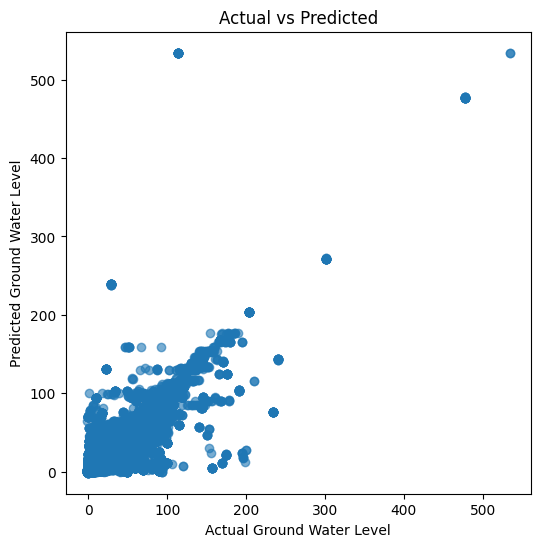

In [10]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel("Actual Ground Water Level")
plt.ylabel("Predicted Ground Water Level")
plt.title("Actual vs Predicted")
plt.show()

In [11]:
xgbr = xgb.XGBRegressor(objective='reg:squarederror', 
                          n_estimators=1000, 
                          max_depth=5,
                          learning_rate=0.05,
                          subsample=0.8,
                          colsample_bytree=0.8,
                          random_state=42)
model_1 = Pipeline(steps=[("pre", preprocessor), ("xgbr", xgbr)])

print("🔄 Training model...")
model_1.fit(X_train, y_train)
print("✅ Training complete.")

🔄 Training model...
✅ Training complete.


In [12]:
y_pred_1 = model_1.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_1)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_1))
r2 = r2_score(y_test, y_pred_1)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 4.634118536162228
RMSE: 7.89574184904282
R²: 0.6286240496597189


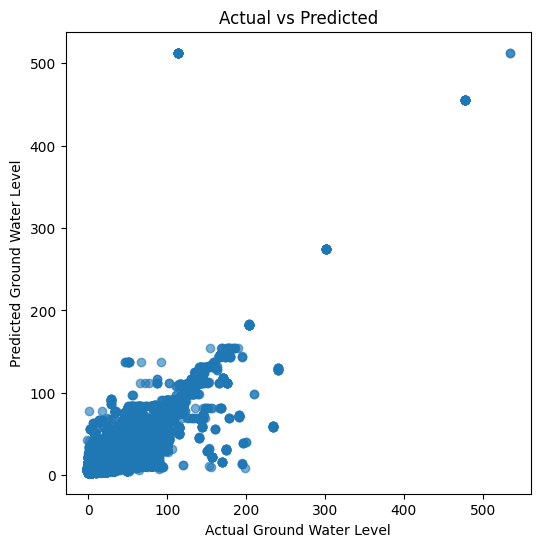

In [13]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_1, alpha=0.6)
plt.xlabel("Actual Ground Water Level")
plt.ylabel("Predicted Ground Water Level")
plt.title("Actual vs Predicted")
plt.show()

In [14]:
import lightgbm as lgb

In [15]:
lgbm_reg = lgb.LGBMRegressor(objective='regression', n_estimators=1000, random_state=42)
model_2 = Pipeline(steps=[("pre", preprocessor), ("lgbm_reg", lgbm_reg)])

print("🔄 Training model...")
model_2.fit(X_train, y_train)
print("✅ Training complete.")

🔄 Training model...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.160000 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 57508
[LightGBM] [Info] Number of data points in the train set: 1864246, number of used features: 28491
[LightGBM] [Info] Start training from score 9.184491
✅ Training complete.


In [16]:
y_pred_2 = model_2.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_2)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_2))
r2 = r2_score(y_test, y_pred_2)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

C:\Users\Lenovo\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


MAE: 3.548045850043747
RMSE: 6.391751772302309
R²: 0.7566296336137305


In [17]:
rf = RandomForestRegressor(n_estimators=50, max_depth=15, random_state=42, n_jobs=-1)
model_3 = Pipeline(steps=[("pre", preprocessor), ("rf", rf)])

print("🔄 Training model...")
model_3.fit(X_train, y_train)
print("✅ Training complete.")

🔄 Training model...
✅ Training complete.


In [18]:
y_pred_3 = model_3.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_3)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_3))
r2 = r2_score(y_test, y_pred_3)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 4.22734987713691
RMSE: 7.675957011327009
R²: 0.6490114391362987


In [27]:
dt = DecisionTreeRegressor(random_state=42)
model_4 = Pipeline(steps=[("pre", preprocessor), ("dt", dt)])
print("🔄 Training model...")
model_4.fit(X_train, y_train)
print("✅ Training complete.")

🔄 Training model...
✅ Training complete.


In [28]:
y_pred_4 = model_4.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_4)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_4))
r2 = r2_score(y_test, y_pred_4)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 1.8149379730564612
RMSE: 5.4278507850687365
R²: 0.8244973432752367
